# Electricity usage prediction from features ()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from keras.layers import Input, Dense, PReLU
from keras.models import Model
from keras.callbacks import EarlyStopping

REZA'S DATA PIPELINE RESULTS IN TRAIN, TEST, LOADED HERE

In [3]:
train_file = "/Users/alanbeem/Desktop/CSB430/Data-Center-Construction-and-Supporting-Utilities-Consumption/REZA/data/train_features.csv"
test_file = "/Users/alanbeem/Desktop/CSB430/Data-Center-Construction-and-Supporting-Utilities-Consumption/REZA/data/test_features.csv"

train_df = pd.read_csv(train_file, index_col=0)
test_df = pd.read_csv(test_file, index_col=0)

In [4]:
test_df.head()

,year,openings,electricity_usage_mwh,water_usage_mgal,cum_dcs,open_lag1,open_lag2,open_lag3,cum_lag1,cum_lag2,roll3,roll5,open_ema3,elec_lag1,elec_growth,elec_growth_3yr,water_lag1,year_num,state_rank,national_momentum
26,2016,0,2731499,NaN,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,2763491.0,-0.011577,-0.011019,NaN,16,39.0,87.000000
27,2017,0,2704890,NaN,0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,2731499.0,-0.009742,-0.006868,NaN,17,39.0,126.333333
28,2018,1,2646058,NaN,1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00,2704890.0,-0.021750,-0.014356,NaN,18,39.0,147.000000
29,2019,0,2638846,NaN,1,1.0,0.0,0.0,1.0,0.0,0.333333,0.2,0.50,2646058.0,-0.002726,-0.011406,NaN,19,39.0,164.333333
30,2020,0,2524116,NaN,1,0.0,1.0,0.0,1.0,1.0,0.333333,0.2,0.25,2638846.0,-0.043477,-0.022651,NaN,20,39.0,160.333333


In [5]:
train_df.head()

,year,openings,electricity_usage_mwh,water_usage_mgal,cum_dcs,open_lag1,open_lag2,open_lag3,cum_lag1,cum_lag2,roll3,roll5,open_ema3,elec_lag1,elec_growth,elec_growth_3yr,water_lag1,year_num,state_rank,national_momentum
3,1993,0,2062399,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2034708.0,0.013609,0.015034,NaN,-7,39.0,0.666667
4,1994,0,2154843,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2062399.0,0.044824,0.024375,NaN,-6,39.0,0.333333
5,1995,0,2200043,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2154843.0,0.020976,0.026470,NaN,-5,39.0,0.666667
6,1996,0,2249874,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2200043.0,0.022650,0.029483,NaN,-4,39.0,1.000000
7,1997,0,2180632,NaN,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2249874.0,-0.030776,0.004283,NaN,-3,39.0,1.666667


TODO PREDICT: ELECTRICITY FROM OTHER DATA, WATER FROM OTHER DATA, DC OPENS FROM OTHER DATA

In [6]:
from sklearn.preprocessing import StandardScaler


X_train = train_df.drop(columns=["electricity_usage_mwh", "water_usage_mgal", "water_lag1"]).astype("float32")
y_train = train_df["electricity_usage_mwh"].astype("float32")
y_train = (y_train - y_train.min()) / (y_train.max() - y_train.min())

X_test = test_df.drop(columns=["electricity_usage_mwh", "water_usage_mgal", "water_lag1"]).astype("float32")
y_test = test_df["electricity_usage_mwh"].astype("float32")
y_test = (y_test - y_test.min()) / (y_test.max() - y_test.min())

X_train = pd.DataFrame(data=StandardScaler().fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(data=StandardScaler().fit_transform(X_test), columns=X_test.columns)

In [7]:
X_train

,year,openings,cum_dcs,open_lag1,open_lag2,open_lag3,cum_lag1,cum_lag2,roll3,roll5,open_ema3,elec_lag1,elec_growth,elec_growth_3yr,year_num,state_rank,national_momentum
0,-1.658312,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.855660,-0.134671,-0.205814,-1.658312,0.887909,-1.346488
1,-1.507557,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.854480,0.129136,-0.071746,-1.507557,0.887909,-1.363674
2,-1.356801,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.850540,-0.072412,-0.041683,-1.356801,0.887909,-1.346488
3,-1.206045,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.848614,-0.058264,0.001568,-1.206045,0.887909,-1.329302
4,-1.055290,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.846490,-0.509793,-0.360104,-1.055290,0.887909,-1.294930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1168,1.055290,-0.323920,-0.355344,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.758385,-0.179328,-0.483039,1.055290,0.273203,1.076742
1169,1.206045,0.138316,-0.288664,-0.312534,-0.295179,-0.278067,-0.343258,-0.330161,-0.348436,-0.354745,-0.354365,-0.756853,-0.458658,-0.467690,1.206045,0.273203,0.698649
1170,1.356801,-0.323920,-0.288664,0.229777,-0.295179,-0.278067,-0.269093,-0.330161,-0.127270,-0.206335,-0.017664,-0.761440,-0.605249,-0.701306,1.356801,0.273203,1.609509
1171,1.507557,-0.323920,-0.288664,-0.312534,0.273368,-0.278067,-0.269093,-0.248680,-0.127270,-0.206335,-0.186015,-0.769053,-0.387993,-0.819423,1.507557,0.273203,1.145486


KERAS REGRESSION

Epoch 1/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0663 - mae: 0.0663 - mse: 0.0120 - val_loss: 0.0793 - val_mae: 0.0793 - val_mse: 0.0229
Epoch 2/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0386 - mae: 0.0386 - mse: 0.0034 - val_loss: 0.0367 - val_mae: 0.0367 - val_mse: 0.0060
Epoch 3/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0298 - mae: 0.0298 - mse: 0.0021 - val_loss: 0.0309 - val_mae: 0.0309 - val_mse: 0.0032
Epoch 4/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - loss: 0.0253 - mae: 0.0253 - mse: 0.0015 - val_loss: 0.0542 - val_mae: 0.0542 - val_mse: 0.0065
Epoch 5/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step - loss: 0.0241 - mae: 0.0241 - mse: 0.0016 - val_loss: 0.0321 - val_mae: 0.0321 - val_mse: 0.0054
Epoch 6/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 0.0210 - mae: 0.0210 - mse: 9.4192e-04 - val_loss: 0.0370 - val_mae: 0.0370 - val_mse: 0.0069
Epoch 7/450
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - loss: 0.0193 - mae: 0.0193 - mse: 9.4992e

<Axes: >

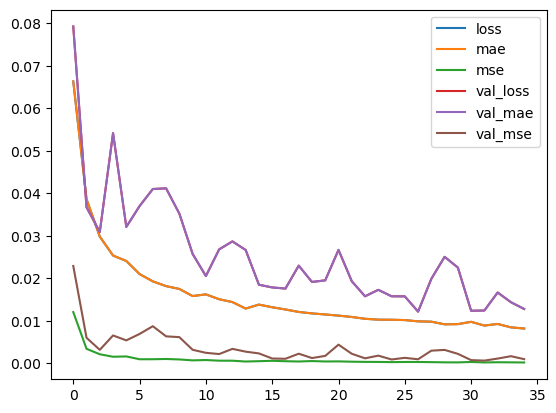

In [ ]:
inputs = Input((17,))
x = Dense(64)(inputs)
x = PReLU()(x)
x = Dense(64)(x)
x = PReLU()(x)
x = Dense(64)(x)
x = PReLU()(x)
outputs = Dense(1)(x)

model = Model(inputs, outputs)
model.compile(optimizer="rmsprop", loss="mae", metrics=["mae", "mse"])
h = model.fit(
    X_train,
    y_train,
    epochs=450,
    batch_size=16,
    verbose=1,
    validation_split=0.2,
    callbacks=[EarlyStopping(patience=8)]
)
pd.DataFrame(h.history).plot()

In [9]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mse:=mean_squared_error(y_test, y_pred))
mae = mean_squared_error(y_test, y_pred)
print('RMSE:', rmse)
print("MAE:", mae)
print("MSE", mse)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
RMSE: 0.02351393133342394
MAE: 0.0005529049667529762
MSE 0.0005529049667529762
